In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from qiskit import qpy

In [2]:
data_dir = Path("../../data/bell_2q_decoherence")

with open(data_dir / "2_circuitsraw_64.qpy", "rb") as f:
    circuits_raw = qpy.load(f)

with open(data_dir / "2_counts_64.json", "r", encoding="utf-8") as f:
    counts = json.load(f)

print("raw circuits:", len(circuits_raw))
print("counts entries:", len(counts))

raw circuits: 64
counts entries: 64


In [3]:
def time_label(i):
    if 0 <= i <= 15:
        return "t0_0dt"
    elif 16 <= i <= 31:
        return "t1_4000dt"
    elif 32 <= i <= 47:
        return "t2_8000dt"
    elif 48 <= i <= 63:
        return "t3_16000dt"
    return "unknown"

def time_us(i):
    block = i // 16
    return [0, 4, 8, 16][block]

In [4]:
rows = []
for i, qc in enumerate(circuits_raw):
    ops = qc.count_ops()
    total_shots = sum(counts[i].values())
    rows.append({
        "index": i,
        "time_block": i // 16,
        "time_label": time_label(i),
        "time_us": time_us(i),
        "basis_index": i % 16,
        "has_delay": "delay" in ops,
        "delay_count": ops.get("delay", 0),
        "shots": total_shots,
        "counts_00": counts[i].get("00", 0),
        "counts_01": counts[i].get("01", 0),
        "counts_10": counts[i].get("10", 0),
        "counts_11": counts[i].get("11", 0),
    })

df = pd.DataFrame(rows)

df["p_00"] = df["counts_00"] / df["shots"]
df["p_01"] = df["counts_01"] / df["shots"]
df["p_10"] = df["counts_10"] / df["shots"]
df["p_11"] = df["counts_11"] / df["shots"]

df.head()

,index,time_block,time_label,time_us,basis_index,has_delay,delay_count,shots,counts_00,counts_01,counts_10,counts_11,p_00,p_01,p_10,p_11
0,0,0,t0_0dt,0,0,False,0,1000,497,17,18,468,0.497,0.017,0.018,0.468
1,1,0,t0_0dt,0,1,False,0,1000,33,496,468,3,0.033,0.496,0.468,0.003
2,2,0,t0_0dt,0,2,False,0,1000,248,263,253,236,0.248,0.263,0.253,0.236
3,3,0,t0_0dt,0,3,False,0,1000,282,248,233,237,0.282,0.248,0.233,0.237
4,4,0,t0_0dt,0,4,False,0,1000,26,483,476,15,0.026,0.483,0.476,0.015


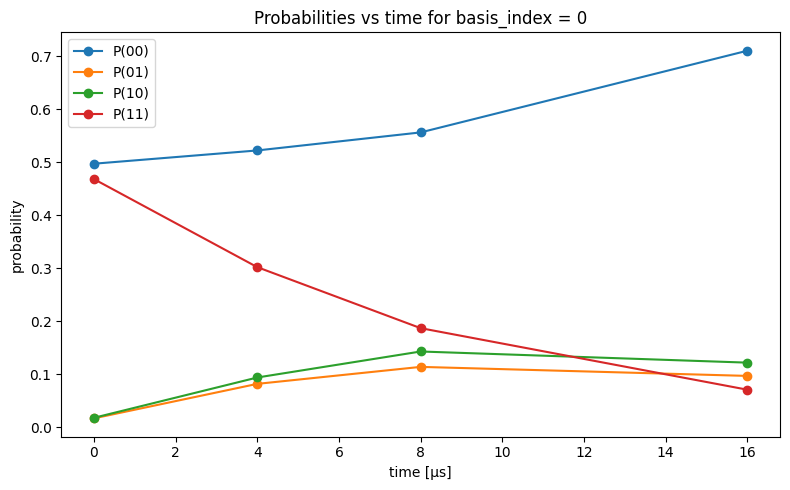

In [5]:
basis_id = 0

sub = df[df["basis_index"] == basis_id].copy()

plt.figure(figsize=(8, 5))
plt.plot(sub["time_us"], sub["p_00"], marker="o", label="P(00)")
plt.plot(sub["time_us"], sub["p_01"], marker="o", label="P(01)")
plt.plot(sub["time_us"], sub["p_10"], marker="o", label="P(10)")
plt.plot(sub["time_us"], sub["p_11"], marker="o", label="P(11)")
plt.xlabel("time [µs]")
plt.ylabel("probability")
plt.title(f"Probabilities vs time for basis_index = {basis_id}")
plt.legend()
plt.tight_layout()
plt.show()

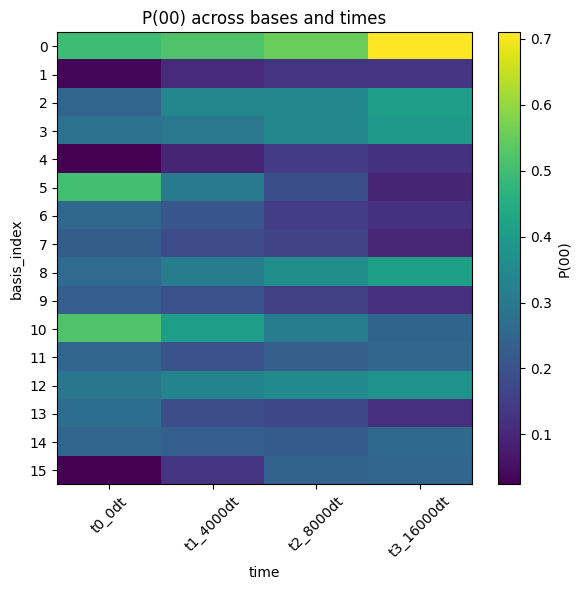

In [6]:
pivot_00 = df.pivot(index="basis_index", columns="time_label", values="p_00")

plt.figure(figsize=(6, 6))
plt.imshow(pivot_00.values, aspect="auto")
plt.xticks(range(len(pivot_00.columns)), pivot_00.columns, rotation=45)
plt.yticks(range(len(pivot_00.index)), pivot_00.index)
plt.xlabel("time")
plt.ylabel("basis_index")
plt.title("P(00) across bases and times")
plt.colorbar(label="P(00)")
plt.tight_layout()
plt.show()

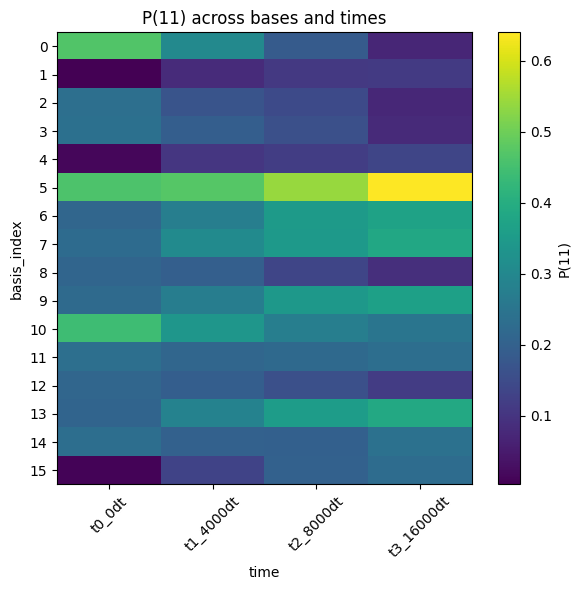

In [7]:
pivot_11 = df.pivot(index="basis_index", columns="time_label", values="p_11")

plt.figure(figsize=(6, 6))
plt.imshow(pivot_11.values, aspect="auto")
plt.xticks(range(len(pivot_11.columns)), pivot_11.columns, rotation=45)
plt.yticks(range(len(pivot_11.index)), pivot_11.index)
plt.xlabel("time")
plt.ylabel("basis_index")
plt.title("P(11) across bases and times")
plt.colorbar(label="P(11)")
plt.tight_layout()
plt.show()